# Análisis Exploratorio de Datos (EDA)

**TFM:** Sistema de Apoyo a la Decisión Clínica en Oncología Pediátrica  
**Autor:** Alonso Castañón González  
**Dataset:** SEER Research Data — Osteosarcoma y Sarcoma de Ewing pediátrico (2000–2023)

**Objetivo de este notebook:** Explorar el dataset limpio generado en `01_limpieza.ipynb`
para comprender la distribución de las variables, su relación con la variable objetivo
(supervivencia a 5 años) y detectar patrones que orienten las decisiones de modelado en
`03_modelo_ML.ipynb`.

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from lifelines.statistics import multivariate_logrank_test

SEED = 2026
np.random.seed(SEED)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 1) Carga del dataset limpio y verificación

Se carga el dataset `seer_osteosarcoma_ewing_clean.csv`, generado como salida final de `01_limpieza.ipynb`. Este notebook parte siempre de dicho archivo para garantizar que la limpieza se ejecuta una única vez y que todos los notebooks posteriores trabajan sobre exactamente la misma versión del dataset.

Antes de cualquier análisis se realiza una verificación para confirmar que el dataset cargado corresponde al resultado documentado en el notebook de limpieza.

In [2]:
# Carga del dataset limpio
DATA_PATH = '../data/seer_osteosarcoma_ewing_clean.parquet'
df = pd.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")

# Verificación de tipos de datos
print("\n---- TIPOS DE DATOS ----")
print(df.dtypes)

# Comprobación de ausencia de valores Blank(s)
n_blanks = (df.astype(str) == 'Blank(s)').sum().sum()
print(f"Valores 'Blank(s)' en el dataset: {n_blanks}")

# Comprobación de los valores NaN por columna
print("\n---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----")
missing_pct = (df.isnull().mean() * 100).round(1)
print(missing_pct[missing_pct > 0])

df.head(5)

Shape: (4915, 15)

---- TIPOS DE DATOS ----
age_group               category
sex                     category
year_diagnosis             int64
tumor_type              category
primary_site            category
stage                   category
tumor_size_cs            float64
surgery_code            category
radiation               category
chemotherapy            category
survival_months            int64
survival_months_flag    category
cause_specific_death    category
vital_status            category
target                     int64
dtype: object
Valores 'Blank(s)' en el dataset: 0

---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----
stage            19.2
tumor_size_cs    61.1
surgery_code      4.3
dtype: float64


,age_group,sex,year_diagnosis,tumor_type,primary_site,stage,tumor_size_cs,surgery_code,radiation,chemotherapy,survival_months,survival_months_flag,cause_specific_death,vital_status,target
0,05-09 years,Female,2004,Ewing sarcoma,Upper limb bones,Regional by direct extension only,64.0,Partial resection,Radiation,Yes,239,complete,Alive / Other cause,Alive,0
1,15-19 years,Male,2001,Ewing sarcoma,Trunk / ribs / sternum,NaN,NaN,Radical resection,No radiation,Yes,275,complete,Alive / Other cause,Alive,0
2,10-14 years,Female,2001,Ewing sarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,119,complete,Dead (cancer),Dead,0
3,10-14 years,Female,2001,Osteosarcoma NOS,Lower limb bones,NaN,NaN,Radical resection,No radiation,Yes,274,complete,Alive / Other cause,Alive,0
4,15-19 years,Female,2000,Chondroblastic osteosarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,23,complete,Dead (cancer),Dead,1


### 1.b) Diccionario de variables

También se documenta el significado clínico, tipo y fuente de cada variable del dataset. Este diccionario sirve como referencia a lo largo de todo el proyecto y permite trazar cada columna hasta su variable original de SEER, dado que varias columnas fueron renombradas y recodificadas en el notebook de limpieza `01_limpieza.ipynb`.

| Variable | Tipo | Significado clínico | Unidad / Categorías | Fuente SEER | % Missing |
|---|---|---|---|---|---|
| `age_group` | categórica ordinal | Grupo de edad al diagnóstico | 00 years, 01-04, 05-09, 10-14, 15-19 | Age recode with <1 year olds and 90+ | 0.0% |
| `sex` | categórica nominal | Sexo del paciente | Female / Male | Sex | 0.0% |
| `year_diagnosis` | numérica discreta | Año de diagnóstico | 2000–2023 | Year of diagnosis | 0.0% |
| `tumor_type` | categórica nominal | Subtipo histológico (ICD-O-3 agrupado) | 9 subtipos (Ewing sarcoma, Osteosarcoma NOS, ...) | Histologic Type ICD-O-3 | 0.0% |
| `primary_site` | categórica nominal | Localización anatómica del tumor primario (agrupada) | 8 grupos (Lower limb bones, Pelvis/hip, ...) | Primary Site | 0.0% |
| `stage` | categórica ordinal | Estadio combinado de extensión tumoral | 5 niveles (Localized only → Distant site(s)/node(s) involved) | Combined Summary Stage (2004+) | 19.2% |
| `tumor_size_cs` | numérica continua | Tamaño del tumor primario | mm (rango real 2–888; solo válido 2004–2015) | CS tumor size (2004-2015) | 61.1% |
| `surgery_code` | categórica nominal | Tipo de cirugía sobre el tumor primario | 4 grupos (No surgery, Partial/Radical resection, NOS/Unknown) | RX Summ--Surg Prim Site (1998-2022) | 4.3% |
| `radiation` | categórica nominal | Administración de radioterapia | 4 grupos (No radiation, Radiation, Recommended/Unknown, Refused) | Radiation recode | 0.0% |
| `chemotherapy` | categórica nominal | Administración de quimioterapia | Yes / No-Unknown | Chemotherapy recode (yes, no/unk) | 0.0% |
| `survival_months` | numérica discreta | Meses de seguimiento desde el diagnóstico | 0–287 meses | Survival months | 0.0% |
| `survival_months_flag` | categórica nominal | Indicador de completitud del dato de seguimiento | complete, complete_zero, incomplete, incomplete_zero | Survival months flag | 0.0% |
| `cause_specific_death` | categórica nominal | Causa de fallecimiento (si aplica) | Alive/Other cause, Dead (cancer), Dead (unknown cause) | SEER cause-specific death classification | 0.0% |
| `vital_status` | categórica nominal | Estado vital al cierre del estudio | Alive / Dead | Vital status recode (study cutoff used) | 0.0% |
| `target` | binaria (0/1) | No supervivencia a 5 años (60 meses) | 0 = sobrevive, 1 = no sobrevive | Derivada de `vital_status` + `survival_months` | 0.0% |

**Nota sobre leakage:** `cause_specific_death`, `vital_status`, `survival_months` y `survival_months_flag`
se usan en el EDA para construir un mejor análisis de supervivencia, pero quedarán excluidas del conjunto que se utilice para los modelos en `03_modelo_ML.ipynb`, al ser variables de seguimiento posteriores al diagnóstico.

## 2) Estadística descriptiva general

Se obtiene una visión general del dataset mediante estadísticos descriptivos: resumen numérico para las variables continuas/discretas, y frecuencias para las variables categóricas. Esto permite detectar rangos, escalas y posibles anomalías.

Además se definen aquí las listas de variables numéricas y categóricas del dataset, que se reutilizarán a lo largo de todo el notebook, evitando redefinirlas en cada sección y separando también en una variable independiente aquellas que producen *data leakage*, con el objetivo de evitar futuros errores.

In [3]:
# Variables numéricas y categóricas del dataset
num_vars = ['year_diagnosis', 'tumor_size_cs', 'survival_months']
cat_vars = ['age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']
leakage_vars = ['survival_months_flag', 'cause_specific_death', 'vital_status']
target_var = 'target'

In [4]:
# Estadística descriptiva de variables numéricas
df[num_vars].describe().round(2)

,year_diagnosis,tumor_size_cs,survival_months
count,4915.00,1910.00,4915.00
mean,2011.69,98.80,96.05
std,6.88,66.05,83.39
min,2000.00,2.00,0.00
25%,2006.00,60.00,24.00
50%,2012.00,88.00,67.00
75%,2018.00,125.00,159.00
max,2023.00,888.00,287.00


In [5]:
# Estadística descriptiva de variables categóricas (incluye leakage_vars para contexto)
df[cat_vars + leakage_vars].describe()

,age_group,sex,tumor_type,primary_site,stage,surgery_code,radiation,chemotherapy,survival_months_flag,cause_specific_death,vital_status
count,4915,4915,4915,4915,3973,4705,4915,4915,4915,4915,4915
unique,5,2,9,8,5,4,4,2,4,3,2
top,15-19 years,Male,Ewing sarcoma,Lower limb bones,Localized only,Radical resection,No radiation,Yes,complete,Alive / Other cause,Alive
freq,1925,2846,2128,2712,1384,2934,3684,4658,4721,3376,3228


### Gráficos descriptivos combinados

Se exploran combinaciones entre variables descriptivas para detectar patrones estructurales
en la muestra, sin utilizar todavía con la variable objetivo.

#### Distribución de edad por sexo

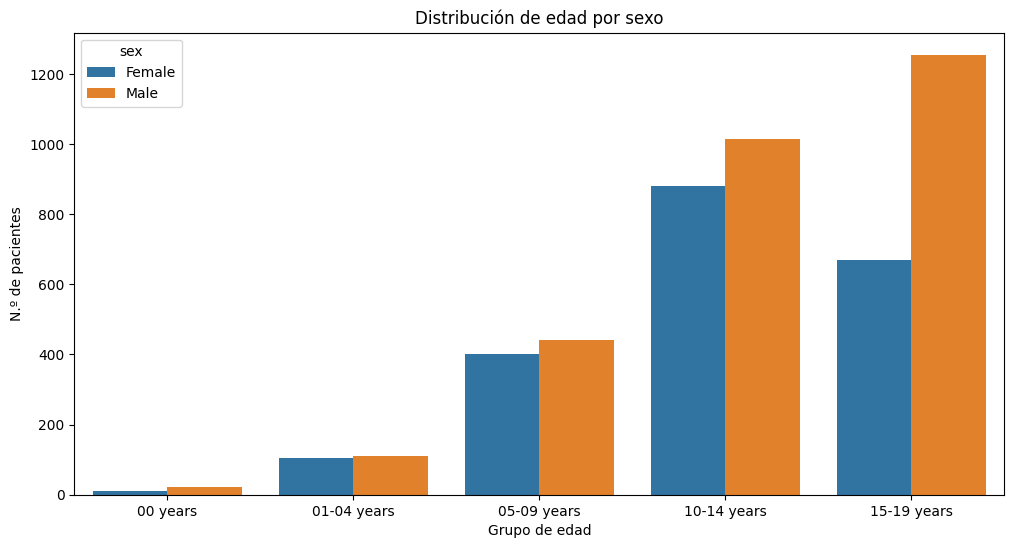

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x='age_group', hue='sex', ax=ax)
ax.set_title('Distribución de edad por sexo')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('N.º de pacientes')
plt.show()

#### Combinación de tratamientos: cirugía y radioterapia

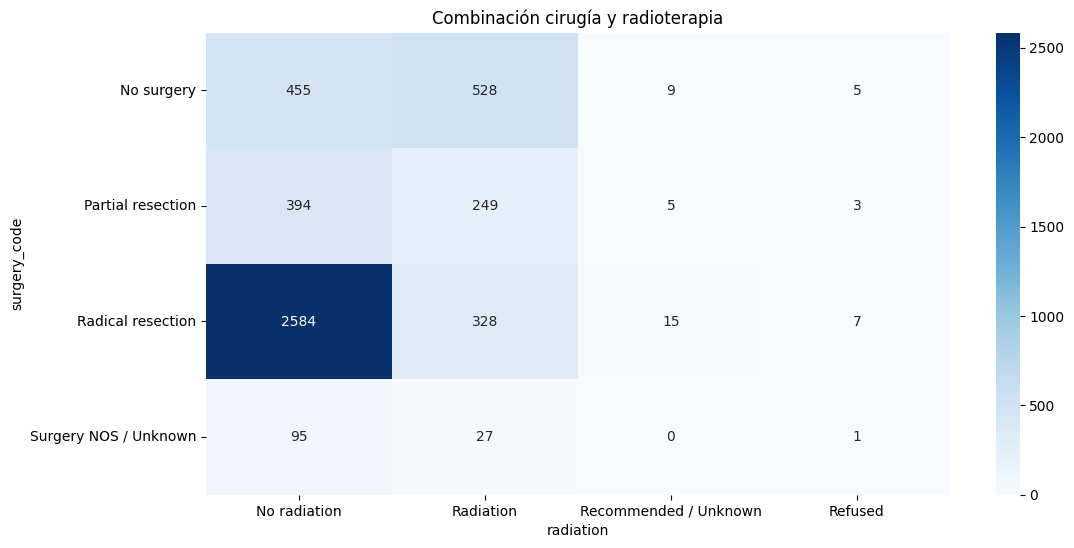

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ct_treat = pd.crosstab(df['surgery_code'], df['radiation'])
sns.heatmap(ct_treat, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Combinación cirugía y radioterapia')
plt.show()

El heatmap anterior está dominado visualmente por *Radical resection + No radiation*, lo que oculta la distribución relativa dentro de cada tipo de cirugía. Se normaliza por fila (% dentro de cada categoría de `surgery_code`) y se añade `chemotherapy` como panel adicional, ya que al tener solo 2 categorías muy desbalanceadas no aportaba valor combinarla en un único heatmap de 3 dimensiones.

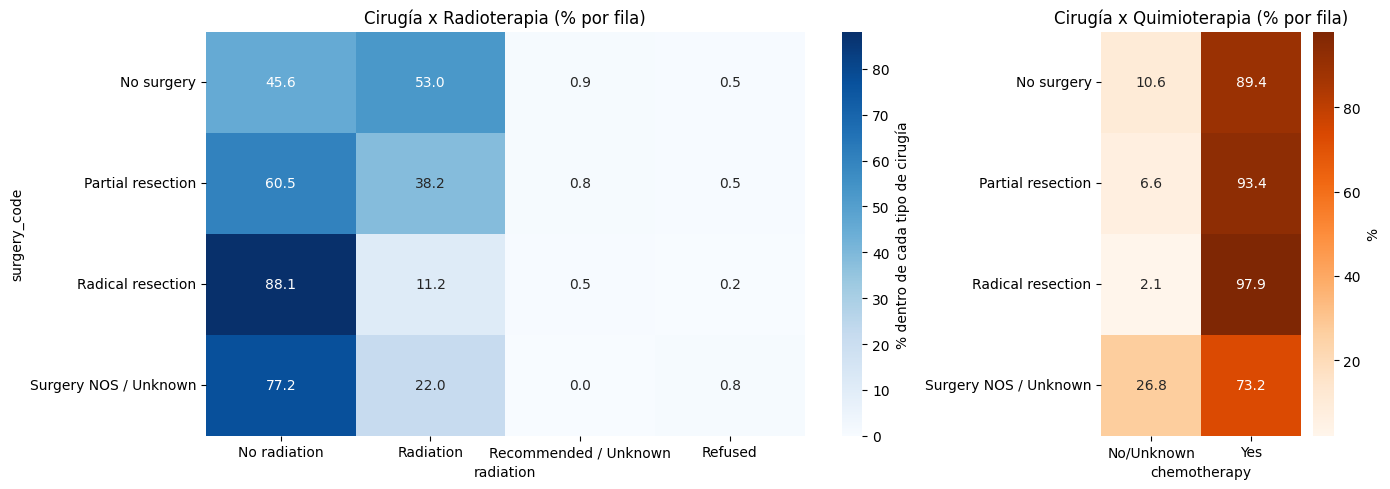

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

# Panel 1: cirugía x radioterapia, normalizado por fila
ct_radiation = pd.crosstab(df['surgery_code'], df['radiation'], normalize='index') * 100
sns.heatmap(ct_radiation, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': '% dentro de cada tipo de cirugía'})
axes[0].set_title('Cirugía x Radioterapia (% por fila)')

# Panel 2: cirugía x quimioterapia, normalizado por fila
ct_chemo = pd.crosstab(df['surgery_code'], df['chemotherapy'], normalize='index') * 100
sns.heatmap(ct_chemo, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': '%'})
axes[1].set_title('Cirugía x Quimioterapia (% por fila)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Se observa que, cuando no hay cirugía, la radioterapia se usa como alternativa en el 53% de los casos, frente a solo 11.2% cuando hay resección radical, siendo coherente con que la radioterapia se reserva como tratamiento local cuando la cirugía no es viable. Y en Surgery NOS/Unknown, tanto la tasa de quimioterapia como la de "No/Unknown" sugieren que esa categoría no solo tiene cirugía mal documentada, sino que probablemente coincide con historias clínicas incompletas en general, lo que puede ser un patrón de calidad de dato a tener en cuenta, no solo clínico.

#### Evolución temporal de diagnósticos por tipo de tumor

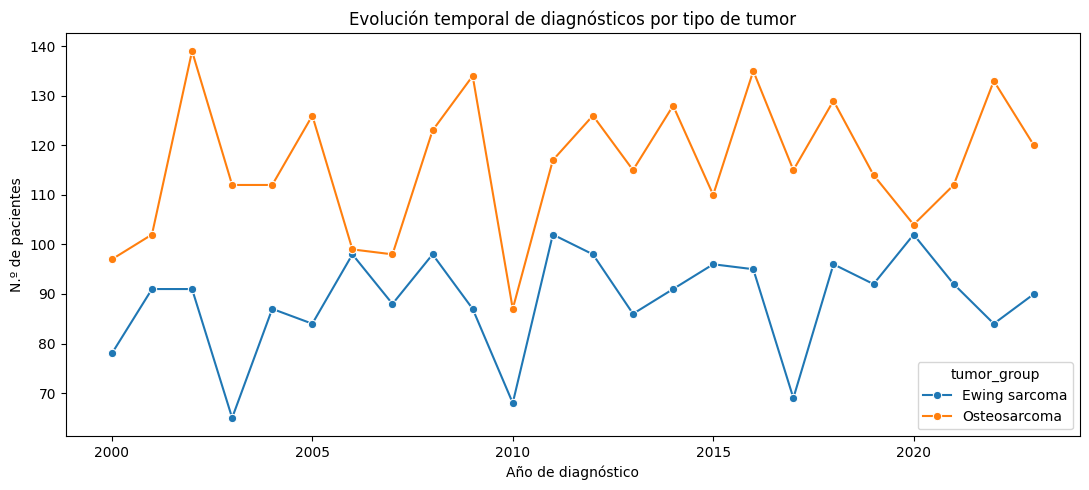

In [9]:
df['tumor_group'] = df['tumor_type'].apply(
    lambda x: 'Ewing sarcoma' if x == 'Ewing sarcoma' else 'Osteosarcoma'
)

temporal = df.groupby(['year_diagnosis', 'tumor_group'], observed=True).size().reset_index(name='n_pacientes')

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=temporal, x='year_diagnosis', y='n_pacientes', hue='tumor_group', marker='o', ax=ax)
ax.set_title('Evolución temporal de diagnósticos por tipo de tumor')
ax.set_xlabel('Año de diagnóstico')
ax.set_ylabel('N.º de pacientes')
plt.tight_layout()
plt.show()

## 3) Distribución de la variable objetivo (target) y desbalanceo

`target` es la variable binaria de no supervivencia a 5 años: 1 si el paciente falleció antes de los 60 meses de seguimiento, 0 si sobrevive o fallece después. Además de comprobar el desbalanceo de esta variable, hay que tener en cuenta cómo funciona el seguimiento de los pacientes. 

Los que siguen vivos cuando termina el estudio de 5 años no sabemos cuándo van a fallecer, solo que, de momento, han sobrevivido más tiempo que el que llevamos observándolos. Esto no es un dato que falte, es un dato que todavía no ha sucedido. En cambio, a los pacientes fallecidos sí les conocemos el momento exacto del evento.

Si tratamos `target` como un simple problema de clasificación desbalanceada sin tener esto en cuenta, podemos tomar decisiones de modelado equivocadas. Por ejemplo, aplicar técnicas para corregir el desbalanceo (como aumentar artificialmente el número de muestras de la clase minoritaria) sin darnos cuenta de que parte de esa "clase mayoritaria" no representa realmente supervivientes confirmados a largo plazo, sino pacientes cuyo desenlace real todavía no conocemos.

In [10]:
# Distribución de la variable objetivo
print("---- DISTRIBUCIÓN DE TARGET ----")
print(df['target'].value_counts())
print((df['target'].value_counts(normalize=True) * 100).round(1))

---- DISTRIBUCIÓN DE TARGET ----
target
0    3520
1    1395
Name: count, dtype: int64
target
0    71.6
1    28.4
Name: proportion, dtype: float64


### Verificación de coherencia entre `target`, `vital_status` y `survival_months`

In [11]:
# Verificación cruzada: todo Dead con target=1 debe tener survival_months < 60
print(pd.crosstab(df['vital_status'], df['target']))

target           0     1
vital_status            
Alive         3228     0
Dead           292  1395


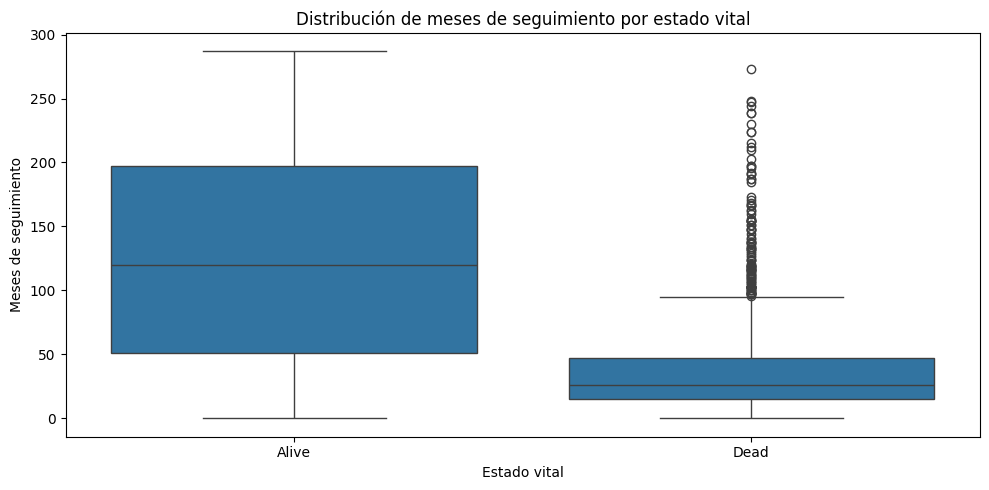

               count   mean   std  min   25%    50%    75%    max
vital_status                                                     
Alive         3228.0  126.7  84.6  0.0  51.0  120.0  197.0  287.0
Dead          1687.0   37.3  36.5  0.0  15.0   26.0   47.0  273.0


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='vital_status', y='survival_months', ax=ax)
ax.set_title('Distribución de meses de seguimiento por estado vital')
ax.set_xlabel('Estado vital')
ax.set_ylabel('Meses de seguimiento')
plt.tight_layout()
plt.show()

print(df.groupby('vital_status', observed=True)['survival_months'].describe().round(1))

Estos datos tambien sirven de ayuda para conocer que los fallecidos tienen una media de 37.3 meses de supervivencia. Es decir, la mayoría de las muertes ocurren dentro de los primeros 2-3 años tras el diagnóstico, muy por debajo del umbral de 5 años (60 meses) que define el target. Esto es coherente con el comportamiento agresivo típico de estos tumores óseos pediátricos: cuando la enfermedad progresa desfavorablemente, suele hacerlo relativamente pronto, mientras que los supervivientes tienden a mantenerse libres de evento a largo plazo (media de seguimiento de 126.7 meses en el grupo `Alive`).

## 4) Análisis univariante

En `01_limpieza.ipynb` se verificó tras cada transformación qué categorías contiene cada columna, pero en este caso se muestran las distribuciones gráficamente ya que puede aportar información adicional (forma de la distribución, comparación visual entre categorías). Para las variables numéricas se visualiza su distribución con un histograma para valorar simetría y modalidad.

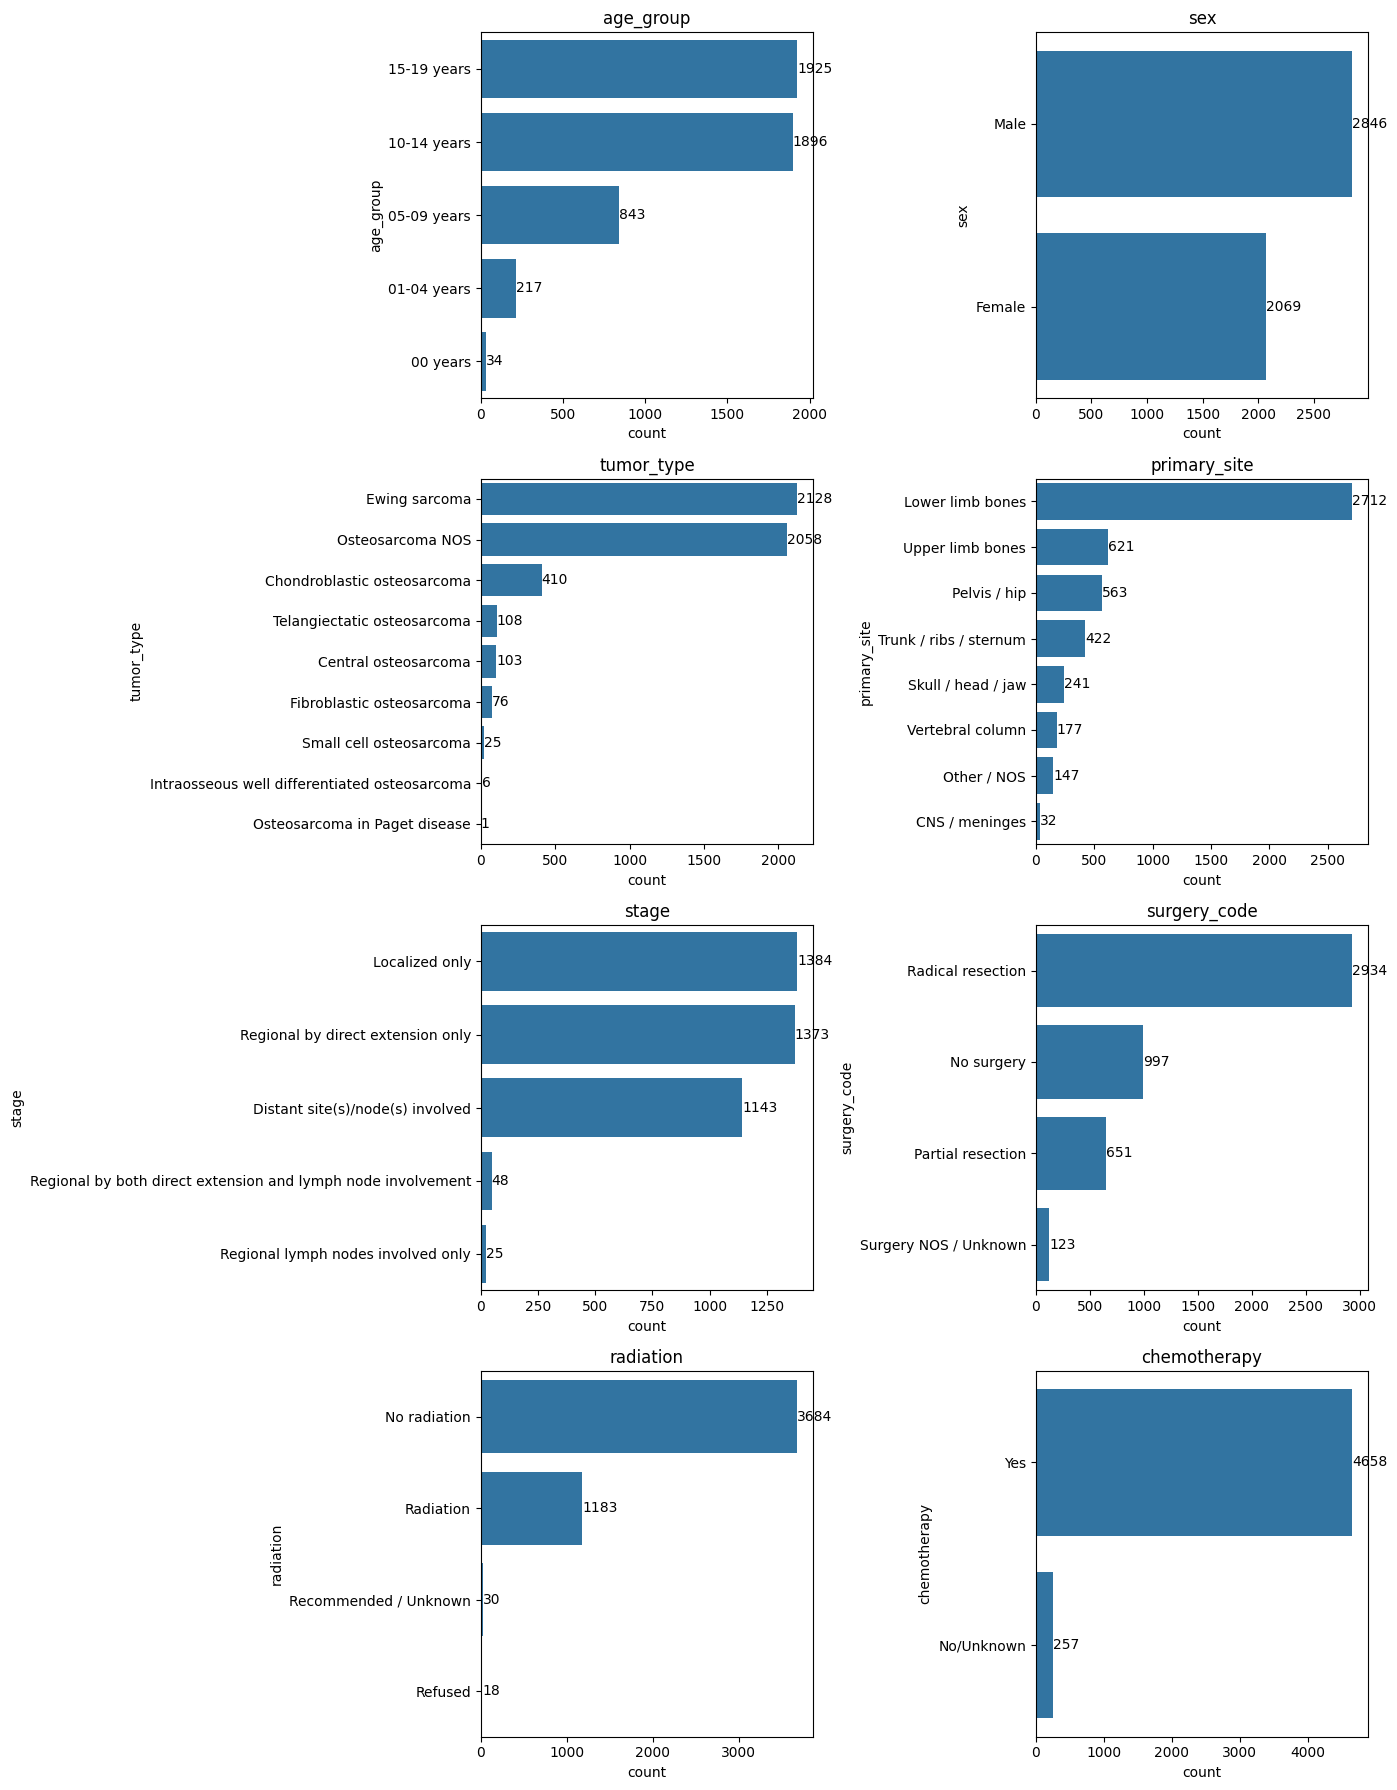

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(cat_vars):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].bar_label(axes[i].containers[0])
plt.tight_layout()
plt.show()

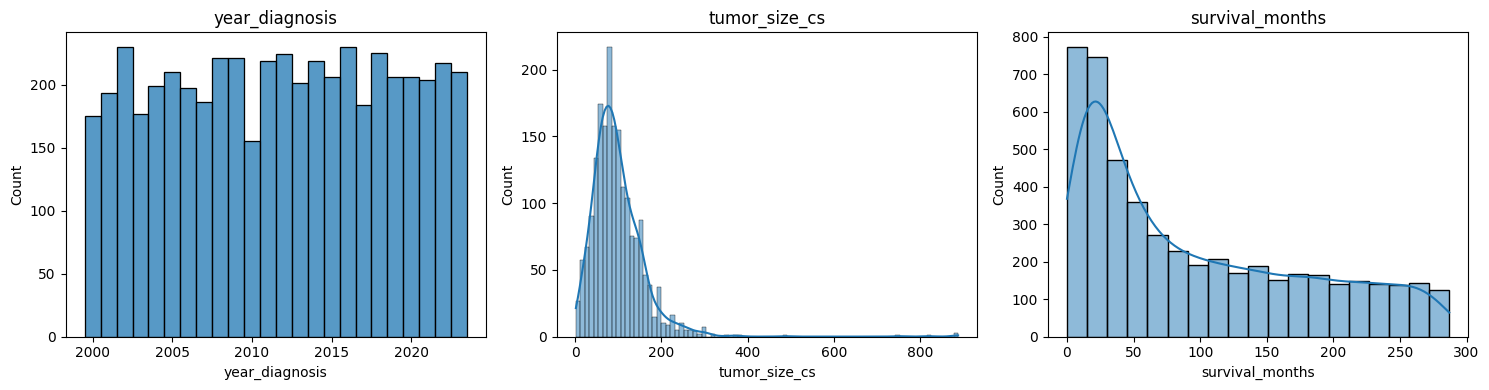

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['year_diagnosis'].dropna(), discrete=True, ax=axes[0])
axes[0].set_title('year_diagnosis')

sns.histplot(df['tumor_size_cs'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('tumor_size_cs')

sns.histplot(df['survival_months'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('survival_months')

plt.tight_layout()
plt.show()

### Interpretación de las distribuciones

**Categóricas:**

- **`age_group`**: la muestra crece con la edad, coherente con la biología de estos tumores, ligados a picos de crecimiento óseo en la adolescencia.
- **`sex`**: predomina el masculino, pero no destacable, no es un desbalanceo extremo.
- **`tumor_type`**: dominado por `Ewing sarcoma` y `Osteosarcoma NOS`. Los otros tipos de osteosarcoma suman muy pocos casos entre todos, confirmando lo ya anotado en `01_limpieza.ipynb` de ser son candidatos claros a agrupar de cara al modelado.
- **`primary_site`**: `Lower limb bones` concentra más de la mitad de la muestra, `CNS/meninges` es la categoría más pequeña, reforzando la decisión de si agruparla con `Other/NOS`.
- **`stage`**: las tres categorías principales (`Localized`, `Regional direct extension`, `Distant`) están relativamente equilibradas entre sí, pero las dos categorías intermedias de afectación ganglionar apenas tienen casos y pueden estar muy poco representadas para el modelo.
- **`surgery_code` / `radiation`**: el patrón de tratamiento dominante es cirugía radical sin radioterapia, coherente con el manejo estándar de tumores óseos (cirugía como tratamiento primario, radioterapia para casos no resecables).
- **`chemotherapy`**: fuertemente desbalanceada, su capacidad predictiva en el modelo puede ser limitada.

**Numéricas:**

- **`year_diagnosis`**: distribución estable año a año, si que se observe tendencia temporal.
- **`tumor_size_cs`**: sesgo marcado a la derecha, con la mayoría de tumores entre 50-150mm y una cola larga de valores extremos hasta 888mm, donde puede haber algunas inconsistencias.
- **`survival_months`**: también sesgada a la derecha, con el pico más alto cerca de 0. Esto combina los fenómenos anticipados en la Sección 3.

**Conclusión:** varias variables categóricas presentan categorías con muy pocos casos, lo que refuerza la necesidad de decidir agrupaciones antes de entrenar el modelo, ya anotado como pendiente en `01_limpieza.ipynb`.

### Revisión de posibles inconsistencias

Además de revisar posibles observaciones duplicadas, a partir de lo observado en las distribuciones anteriores se revisan en detalle los puntos concretos que generaron sospecha: la cola de valores extremos en `tumor_size_cs` y el pico de `survival_months` cercano a 0.

In [15]:
print("---- tumor_size_cs: valores extremos (>400mm) ----")
df[df['tumor_size_cs']>400][['tumor_size_cs','tumor_type','primary_site','age_group']]

---- tumor_size_cs: valores extremos (>400mm) ----


,tumor_size_cs,tumor_type,primary_site,age_group
725,750.0,Osteosarcoma NOS,Lower limb bones,10-14 years
1783,888.0,Ewing sarcoma,Trunk / ribs / sternum,10-14 years
2556,486.0,Osteosarcoma NOS,Skull / head / jaw,05-09 years
4131,820.0,Chondroblastic osteosarcoma,Lower limb bones,15-19 years
4214,888.0,Osteosarcoma NOS,Lower limb bones,15-19 years
4668,888.0,Ewing sarcoma,Upper limb bones,10-14 years


In [16]:
print("---- survival_months = 0: desglose por vital_status ----")
df[df['survival_months']==0]['vital_status'].value_counts()

---- survival_months = 0: desglose por vital_status ----


vital_status
Alive    22
Dead      7
Name: count, dtype: int64

In [17]:
print("---- Filas duplicadas exactas ----")

n_duplicados = df.duplicated().sum()
dup_rows = df[df.duplicated(keep=False)]
print(n_duplicados)
print(f"% de duplicados con tumor_size_cs NaN: {dup_rows['tumor_size_cs'].isnull().mean()*100:.1f}% (vs {df['tumor_size_cs'].isnull().mean()*100:.1f}% general)")

---- Filas duplicadas exactas ----
74
% de duplicados con tumor_size_cs NaN: 100.0% (vs 61.1% general)


### Interpretación de las inconsistencias revisadas

**`tumor_size_cs` > 400mm (6 casos):** todos entran dentro del rango técnicamente válido por el SEER. La mayoría aunque extraños, son posibles, ya que los tumores en huesos largos de extremidades pueden alcanzar tamaños considerables si el diagnóstico se retrasa. El caso más llamativo es el de 486mm en `Skull / head / jaw` (05-09 years). Un tumor de ese tamaño en
una localización craneofacial es muy poco probable en un niño de esa edad, y no encaja con el patrón comentado. Se señala como candidato a revisión en el modelado, sin eliminarlo aquí por no poder confirmar si es un error de registro.

**`survival_months = 0` (29 casos, 22 vivos + 7 fallecidos):** ambos grupos son clínicamente posibles. Los 7 fallecidos con 0 meses son casos de muerte muy temprana tras el diagnóstico
(evento real, coherente con la agresividad de estos tumores). Los 22 vivos con 0 meses corresponden a diagnósticos muy recientes, próximos al corte del estudio (Nov 2025 submission), sin tiempo de seguimiento aún acumulado. Ninguno de los dos subgrupos representa un error.

**Filas duplicadas exactas (74):** el 100% de estas filas tiene valores NaN en `tumor_size_cs` . Esto no es casualidad ya que cuando las variables con más posibles valores (`tumor_size_cs`, `survival_months`) coinciden por estar vacías, el resto de columnas tienen pocas categorías posibles, lo que reduce drásticamente el espacio combinatorio real y hace mucho más probable la coincidencia entre pacientes distintos. SEER Research Data no incluye identificador de paciente, por lo que no puede se confirmar con certeza si son pacientes distintos o registros repetidos por error. Se decide mantener estas filas en este dataset limpio, ya que no hay evidencia de error que justifique eliminarlas en este momento. Sin embargo, de cara al modelado hay un motivo distinto y más sólido para eliminarlas: el riesgo de **data leakage en la división train/test**. Al no existir identificador de paciente, una fila y su duplicado exacto podrían quedar repartidos entre ambos conjuntos, permitiendo que el modelo posea durante el entrenamiento un caso idéntico al que luego se usa para evaluarlo. Este riesgo se ve además reforzado por la imputación: cualquier método como la media, mediana, KNN o regresión asignará el mismo valor de `tumor_size_cs` a estas filas, al partir de la misma información en el resto de columnas, por lo que seguirán siendo duplicadas después de imputar, agravando el problema de leakage si no se eliminan antes del train/test. 

**Conclusión:** ningún hallazgo de esta revisión justifica modificar el dataset en esta fase. Los puntos a trasladar al notebook de modelado son el caso de 486mm en localización craneofacial como candidato puntual a verificación y la eliminación de estas 74 filas, que se aplicará justo antes de dividir en train/test.

## 5) Análisis bivariante respecto al target

Para cada variable se evalúa su asociación con `target` mediante gráfico + test estadístico:

**Chi-cuadrado (χ²)** se usa para las variables categóricas frente a `target`. Compara las proporciones observadas de supervivencia/no supervivencia en cada categoría frente a las proporciones que se esperarían si no hubiera ninguna relación entre la variable y la objetivo. Es el test estándar para evaluar independencia entre dos variables categóricas, y no requiere asumir ninguna distribución concreta de los datos.

**Mann-Whitney U** se usa para las variables numéricas frente a `target`, en lugar de un t-test clásico. El t-test asume que los datos siguen una distribución normal en cada grupo, y ya se
comprobó en la Sección 4 que `tumor_size_cs` y `survival_months` presentan sesgo marcado a la derecha, y con t-test daría un resultado poco fiable. Mann-Whitney
compara si los valores de un grupo tienden a ser sistemáticamente mayores o menores que los del otro, sin importar la forma de la distribución.

En ambos casos se considera significativa una asociación con p<0.05, aunque conviene recordar que eso no implica necesariamente importancia clínica.

### Análisis bivariante: variables categóricas

Variable              chi2   dof      p-valor
age_group            72.57     4    6.493e-15  ***
sex                  14.17     1    0.0001674  ***
tumor_type           43.04     8    8.641e-07  ***
primary_site         61.04     7    9.372e-11  ***
stage               428.94     4    1.549e-91  ***
surgery_code        115.06     3    8.943e-25  ***
radiation             8.05     3      0.04504  *
chemotherapy          3.13     1      0.07699  ns


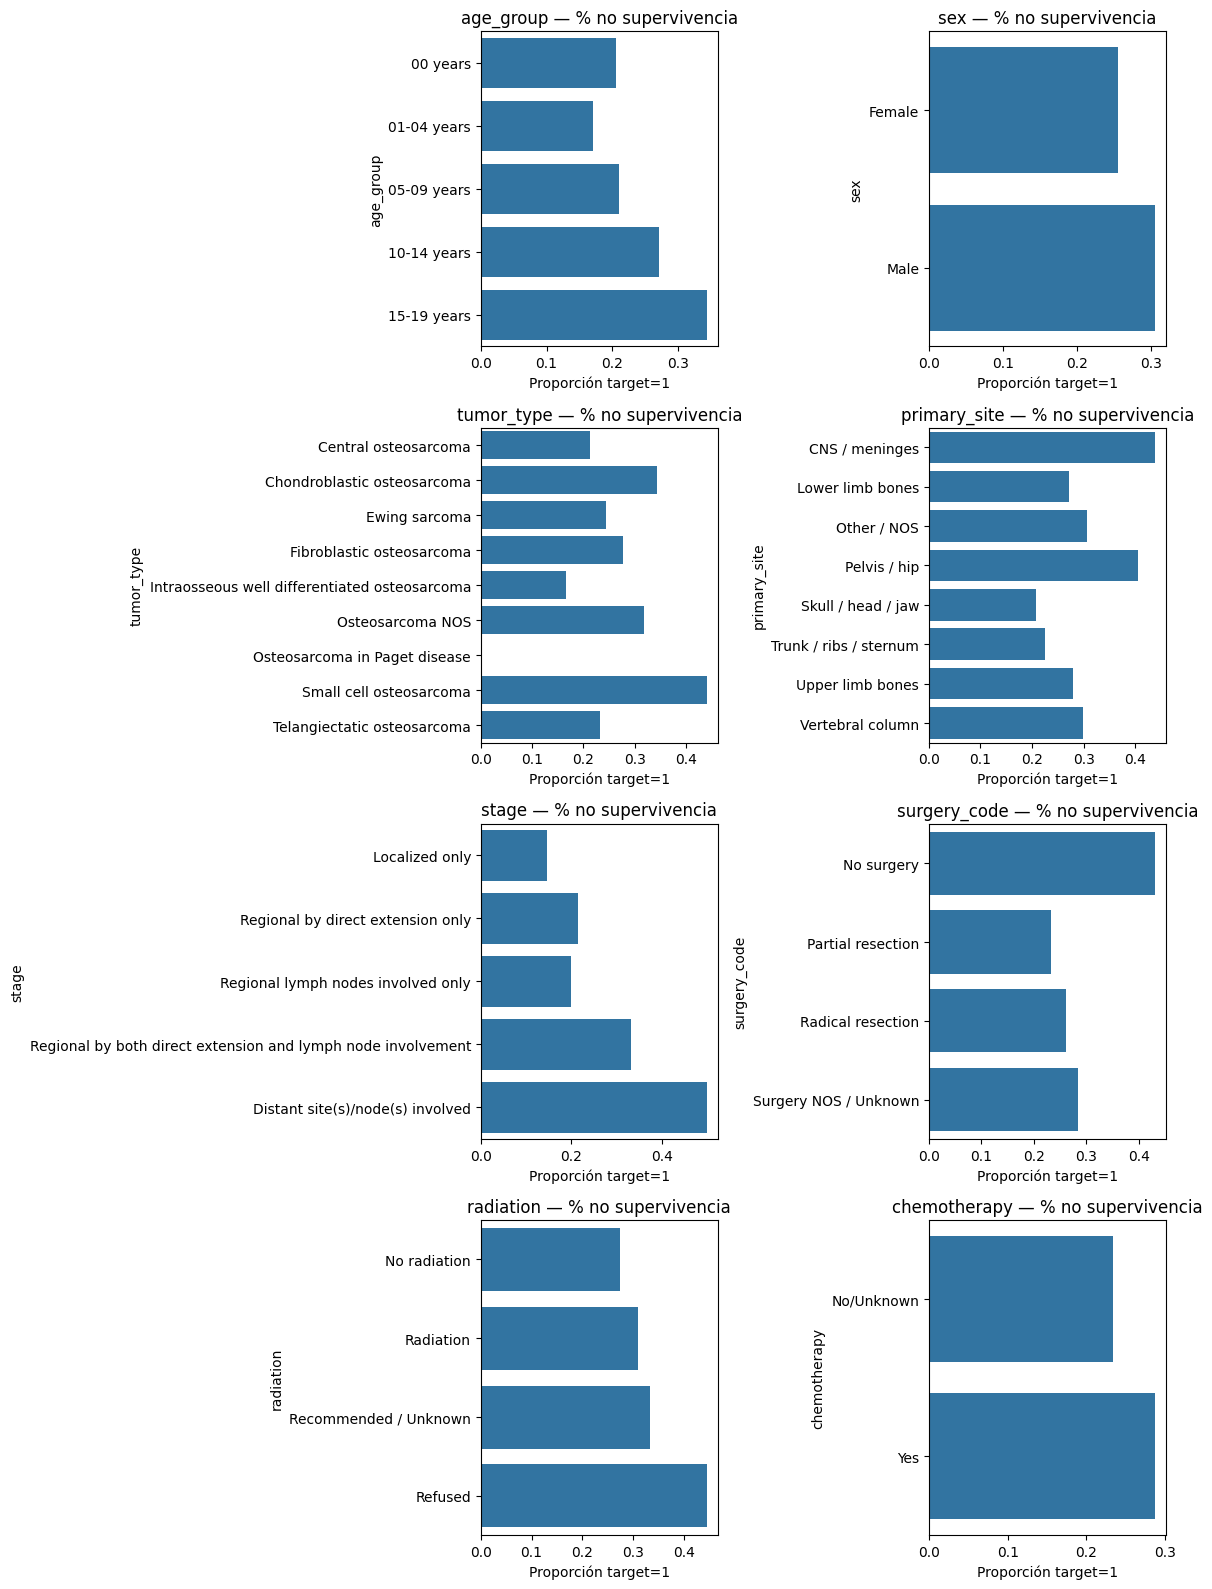

In [ ]:
print(f"{'Variable':<15} {'chi2':>10} {'dof':>5} {'p-valor':>12}")
for col in cat_vars:
    ct = pd.crosstab(df[col], df['target'])
    chi2, p, dof, exp = chi2_contingency(ct)
    sig = '***' if p<0.001 else ('*' if p<0.05 else 'ns')
    print(f"{col:<15} {chi2:>10.2f} {dof:>5} {p:>12.4g}  {sig}")


fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()
for i, col in enumerate(cat_vars):
    prop = df.groupby(col, observed=True)['target'].mean().sort_values(ascending=False)
    sns.barplot(x=prop.values, y=prop.index, ax=axes[i])
    axes[i].set_title(f'{col} — % no supervivencia')
    axes[i].set_xlabel('Proporción target=1')
plt.tight_layout()
plt.show()

- **`stage`**: el patrón más claro y clínicamente coherente de todos. La mortalidad crece de forma casi monótona con la extensión del tumor: `Localized` → `Regional` → `Distant`. Es con diferencia la variable con mayor chi2, por lo que parece que es el factor dominante de predicción.
- **`surgery_code`**: patrón muy marcado, `No surgery` tiene la mortalidad más alta con claridad frente al resto de categorías. Esto tiene sentido ya que no operar suele indicar que la enfermedad ya está demasiado extendida.
- **`primary_site`**: `Pelvis/hip`  y `CNS/meninges` destacan con peor pronóstico frente al resto. Puede ser debido a que ambas localizaciones dificultan la resección completa.
- **`age_group`**: tendencia creciente con la edad.
- **`sex`**: diferencia pequeña pero significativa.
- **`tumor_type`**: mucha variabilidad entre subtipos, pero es que hay varios que tienen muy pocos casos como ya vimos.
- **`radiation`**: significativo pero con rl p-valor más alta de las significativas y cerca del límite. `Refused` muestra la peor mortalidad, aunque probablemente sea más causado porque se rechaza el tratamiento en casos ya muy avanzados a que sea un efecto del rechazo en sí.
- **`chemotherapy`**: única variable no significativa, coherente con el fuerte desbalanceo ya visto.

### Análisis bivariante: variables numéricas

Variable                p-valor   mediana target=0   mediana target=1
year_diagnosis        6.825e-18             2012.5             2010.0
tumor_size_cs         1.073e-15               82.0              101.0
survival_months               0              114.0               21.0


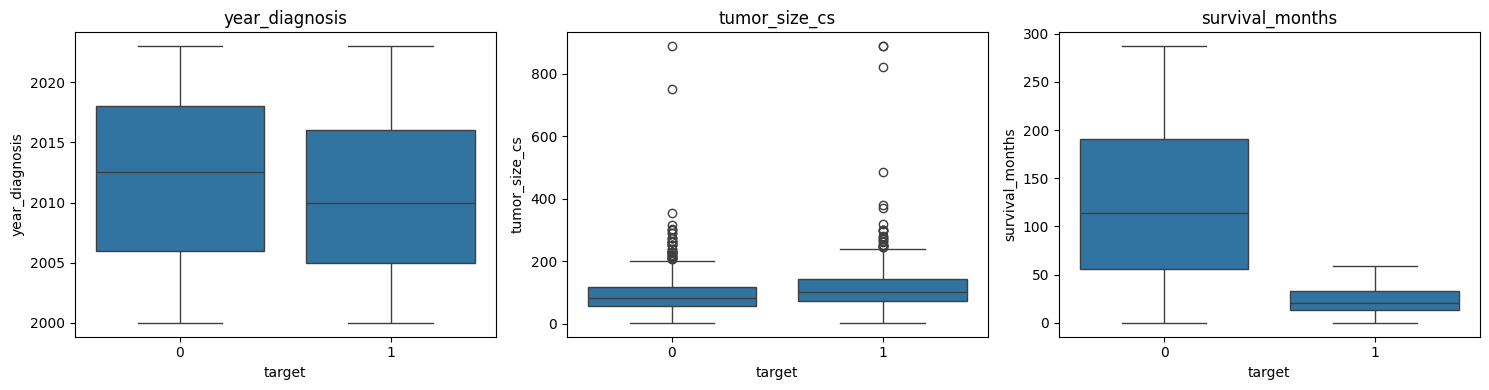

In [26]:
print(f"{'Variable':<18} {'p-valor':>12} {'mediana target=0':>18} {'mediana target=1':>18}")
for col in num_vars:
    g0 = df[df['target']==0][col].dropna()
    g1 = df[df['target']==1][col].dropna()
    u, p = mannwhitneyu(g0, g1, alternative='two-sided')
    print(f"{col:<18} {p:>12.4g} {g0.median():>18.1f} {g1.median():>18.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_vars):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

- **`tumor_size_cs`**: los boxplots muestran cajas parecidas, pero el grupo `target=1` tiene la mediana algo más alta y también concentra los valores extremos más altos como se vio en la Sección 4.
- **`year_diagnosis`**: diferencia de medianas pequeña. También se puede ver una ligera mejora de la supervivencia en años más recientes.
- **`survival_months`**: es la variable que define `target`, su diferencia entre grupos no aporta información nueva.

**Conclusión para el modelado:** `stage`, `surgery_code` y `primary_site` emergen como las variables con la asociación más clara y clínicamente interpretable con la supervivencia, mientras que `chemotherapy` aporta poca señal por su desbalanceo. Esto es coherente con la literatura clínica sobre pronóstico en sarcomas óseos pediátricos, lo que da confianza en la calidad del dataset antes de pasar al modelado.

## 6) Análisis de valores perdidos

Se verifica visualmente el mecanismo MAR (Missing At Random condicionado a `year_diagnosis`) que se documenta en `01_limpieza.ipynb` para `stage`, `tumor_size_cs` y `surgery_code`.

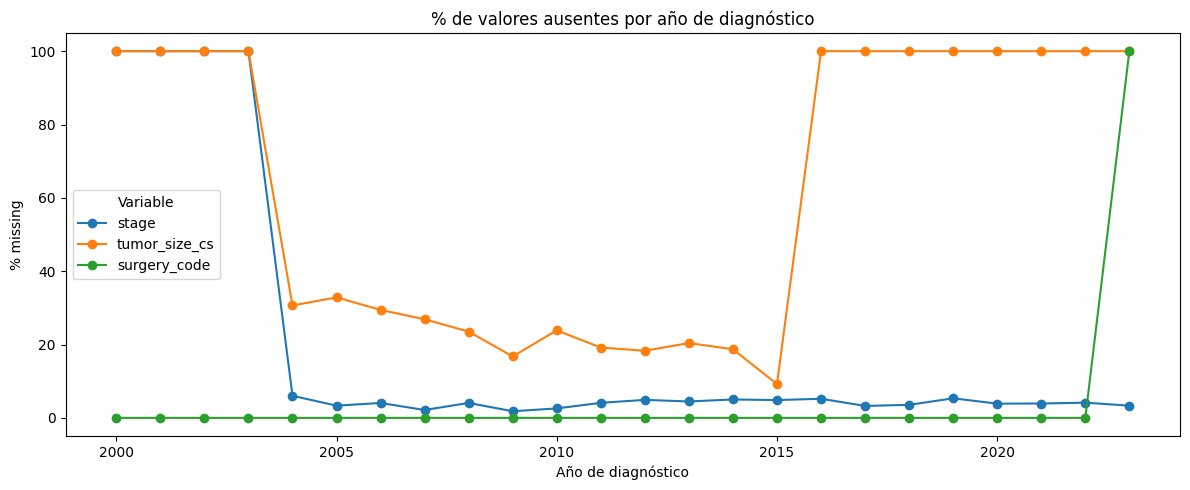

In [28]:
missing_by_year = df.groupby('year_diagnosis').apply(
    lambda g: pd.Series({
        'stage': g['stage'].isnull().mean() * 100,
        'tumor_size_cs': g['tumor_size_cs'].isnull().mean() * 100,
        'surgery_code': g['surgery_code'].isnull().mean() * 100,
    }), include_groups=False
)

fig, ax = plt.subplots(figsize=(12, 5))
missing_by_year.plot(marker='o', ax=ax)
ax.set_title('% de valores ausentes por año de diagnóstico')
ax.set_xlabel('Año de diagnóstico')
ax.set_ylabel('% missing')
ax.legend(title='Variable')
plt.tight_layout()
plt.show()

### Interpretación

El gráfico confirma que los tres patrones de missing están **condicionados al año de diagnóstico**, no a las características clínicas del paciente.

- **`stage`**: 100% ausente en 2000-2003 (antes del sistema de estadificación combinada), 2004 en adelante porcentaje de valores perdidos mas aceptables.
- **`tumor_size_cs`**: 100% ausente fuera de la ventana 2004-2015 por diseño del registro.
- **`surgery_code`**: 0% de missing en todos los años excepto 100% en 2023. La variable original de SEER, `RX Summ--Surg Prim Site (1998-2022)`, no cubre el año más reciente.
  
**Implicación para el modelado:** ninguno de los tres missing es aleatorio respecto al paciente ya que los tres dependen de cuándo se diagnosticó. Esto justifica que no debe aplicarse un `dropna()` que descarte una proporción muy alta de la muestra sin necesidad. Por otro lado, no conviene una imputación global, por ejemplo, rellenando `tumor_size_cs` con la mediana de todo el dataset. Como el dato está ausente por diseño fuera de 2004-2015, se estaría inventando un tamaño de tumor para un paciente de 2020 basándose en pacientes de 2004-2015, siendo dos épocas distintas sin garantía de que el tamaño típico sea comparable entre ambas (mejoras en detección precoz, cambios de protocolo, etc.). En la práctica, esto no reduce la muestra, `tumor_size_cs` ya se descartó como predictor principal en `01_limpieza.ipynb` por este mismo motivo (quedando como línea opcional un submodelo solo con los ~1.910 pacientes de 2004-2015), y `surgery_code` afecta solo a los 210 pacientes de 2023, que pueden dejarse como `NaN` sin excluir filas. `stage` sí requiere una decisión más cuidadosa por su capacidad de pronóstico.

## 7) Curvas de Kaplan-Meier (con log-rank test)

**Kaplan-Meier** estima la probabilidad de que un paciente siga vivo a medida que pasa el tiempo desde el diagnóstico. El eje X es el tiempo (meses), el eje Y es la probabilidad de supervivencia, siempre entre 0 y 100%. La curva empieza en 1 porque es el momento del diagnóstico, el 100% de los pacientes está vivo, y va bajando en escalones cada vez que se produce un fallecimiento. Cuanto más pronunciada la caída, más eventos ocurren en ese tramo de tiempo.

Es importante no confundir la curva con un recuento simple de vivos/muertos. En cada instante, la probabilidad se recalcula solo sobre los pacientes que en ese momento siguen en riesgo (los que llevan seguimiento suficiente para haber podido fallecer ya, y no han sido censurados antes). Esto permite aprovechar toda la información disponible, incluida la de pacientes con seguimiento incompleto, sin descartarlos ni tratarlos como si hubieran sobrevivido con certeza.

Cuando se comparan varias curvas, por ejemplo, una por cada `stage`, el **test de log-rank** sirve para saber si la diferencia entre estas curvas es real o podría deberse al azar. Compara, en cada momento en que ocurre un evento, cuántos fallecimientos se observan en cada grupo frente a los que se esperarían si todos los grupos tuvieran la misma supervivencia. Un p-valor pequeño (<0.05) indica que las curvas son realmente distintas entre sí.

En esta sección, se estima la función de supervivencia mediante el estimador de Kaplan-Meier, que es la estándar en oncología para datos de supervivencia censurados: `survival_months` como tiempo hasta el evento, y `vital_status = Dead` como evento observado (los pacientes vivos al cierre del estudio son censurados por la derecha). Para cada comparación entre grupos se aplica el test de log-rank.

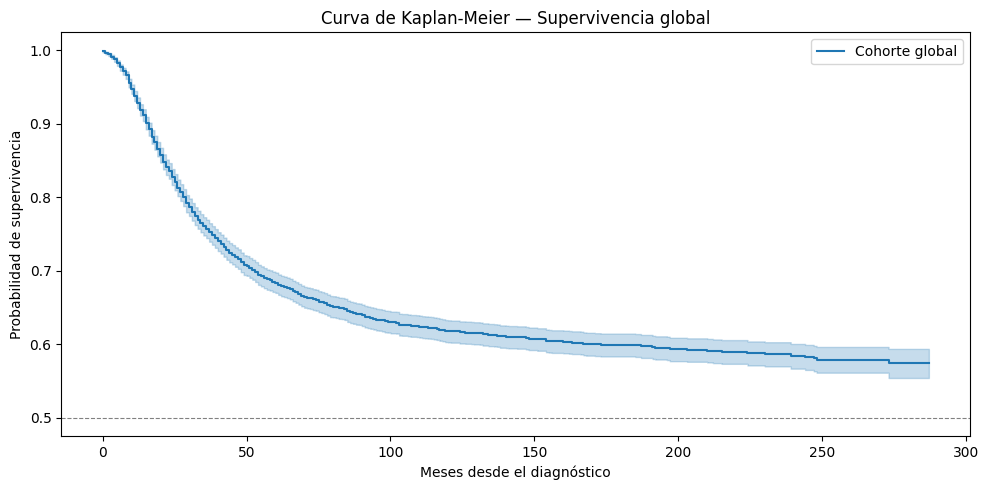

Supervivencia a 60 meses (5 años): 68.4%
Supervivencia mínima observada (fin de seguimiento): 57.4%


In [29]:
df['event'] = (df['vital_status'] == 'Dead').astype(int)

kmf = KaplanMeierFitter()
kmf.fit(df['survival_months'], event_observed=df['event'], label='Cohorte global')

fig, ax = plt.subplots(figsize=(10, 5))
kmf.plot_survival_function(ax=ax)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Curva de Kaplan-Meier — Supervivencia global')
ax.set_xlabel('Meses desde el diagnóstico')
ax.set_ylabel('Probabilidad de supervivencia')
plt.tight_layout()
plt.show()

print(f"Supervivencia a 60 meses (5 años): {kmf.survival_function_at_times(60).values[0]*100:.1f}%")
print(f"Supervivencia mínima observada (fin de seguimiento): {kmf.survival_function_.min().values[0]*100:.1f}%")

**Análisis de la curva:** caída pronunciada en los primeros 50-60 meses de 100% a 70% aproximadamente, y a partir de ahí se aplana notablemente. La mayoría de los eventos ocurren en los primeros 5 años, coherente con lo visto en la Sección 3 (mediana de supervivencia en `Dead` de 26 meses). La supervivencia a 5 años estimada por Kaplan-Meier (68.4%) es algo más baja que el 71.6% de `target=0` visto en la Sección 3. Esto es una diferencia esperable ya que `target=0` cuenta como "superviviente" a cualquier paciente que no conste como fallecido antes de 60 meses, incluidos los diagnosticados recientemente que aún no han acumulado ese tiempo de seguimiento (su desenlace real a 5 años todavía se desconoce). Kaplan-Meier, en cambio, retira a esos pacientes del cálculo en el momento exacto en que se pierde su seguimiento, sin asumir que "sobrevivieron". La diferencia sugiere que `target`, como etiqueta binaria simple, es ligeramente optimista respecto a la probabilidad real de supervivencia a 5 años. La mediana de supervivencia global es infinita porque la curva nunca cae por debajo del 50% dentro del periodo observado.

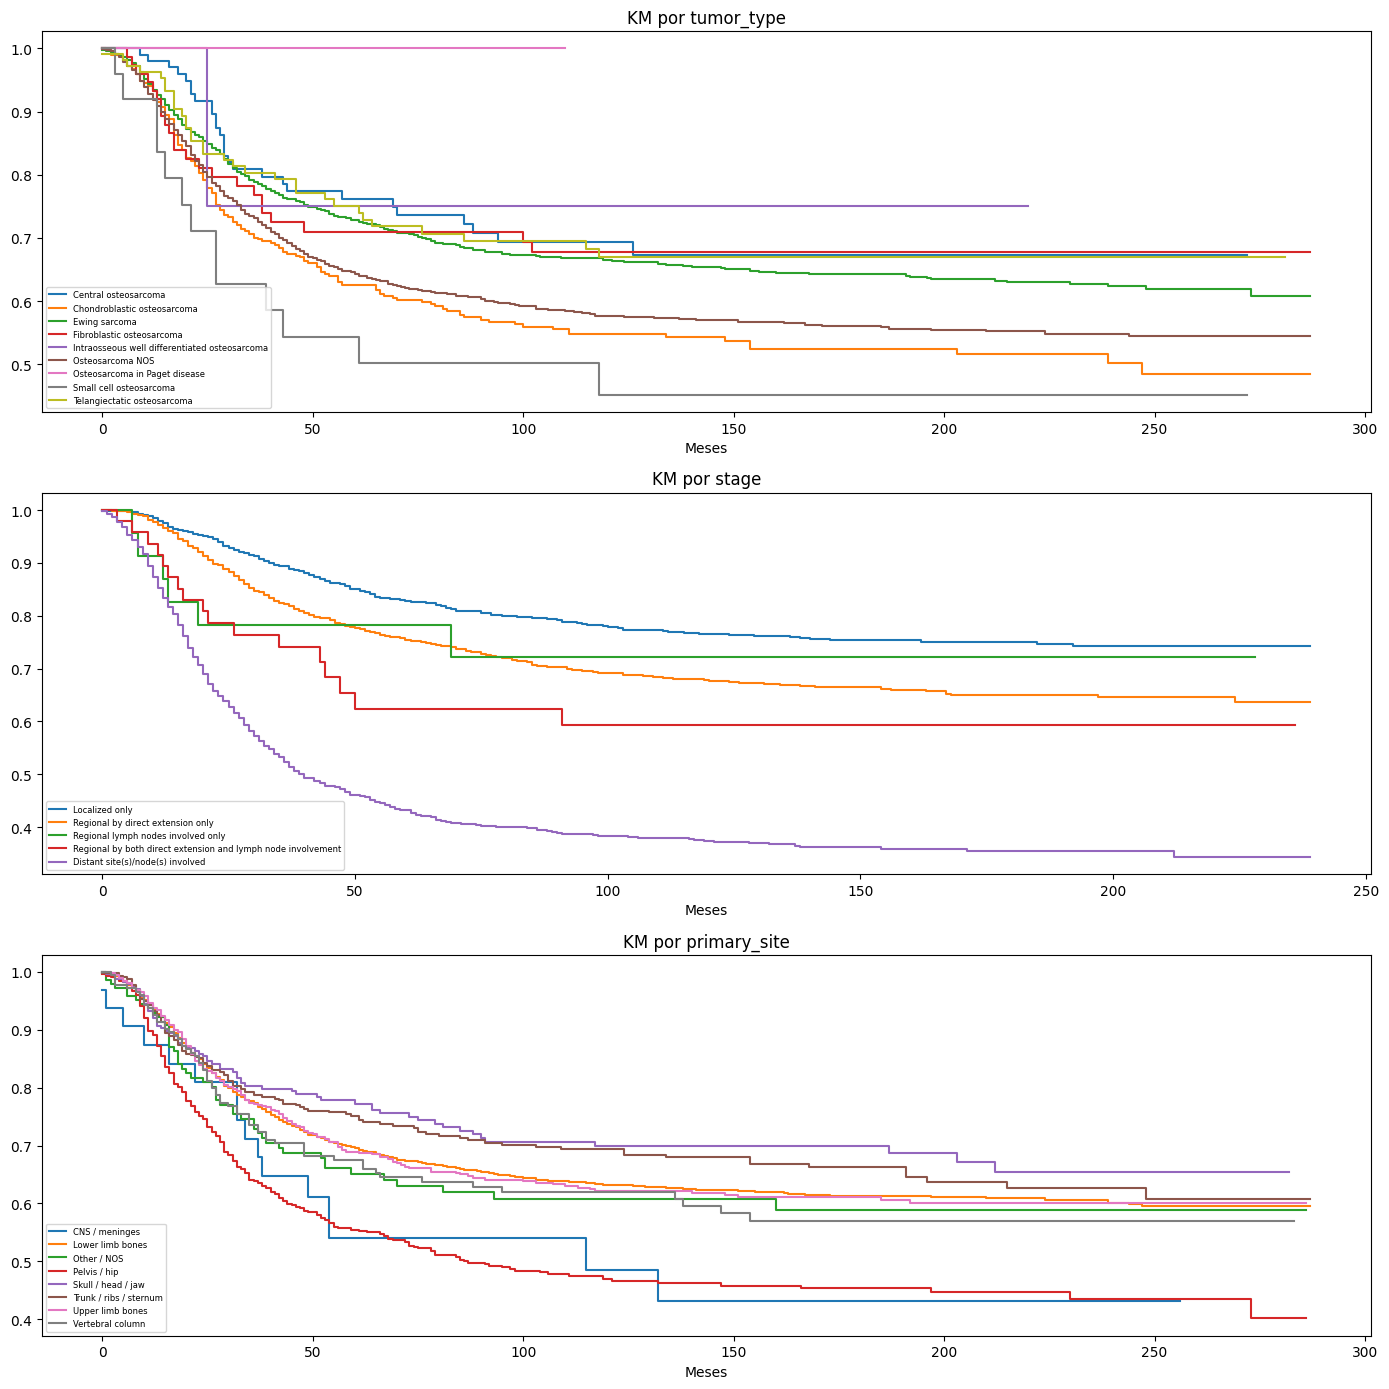

Log-rank tumor_type: p-valor = 3.572e-07
Log-rank stage: p-valor = 2.904e-117
Log-rank primary_site: p-valor = 1.063e-12


In [40]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, group_col in zip(axes, ['tumor_type', 'stage', 'primary_site']):
    for name, grp in df.groupby(group_col, observed=True):
        kmf = KaplanMeierFitter()
        kmf.fit(grp['survival_months'], event_observed=grp['event'], label=str(name))
        kmf.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(f'KM por {group_col}')
    ax.set_xlabel('Meses')
    ax.legend(fontsize=6, loc='lower left')

plt.tight_layout()
plt.show()

for group_col in ['tumor_type', 'stage', 'primary_site']:
    res = multivariate_logrank_test(df['survival_months'], df[group_col], df['event'])
    print(f"Log-rank {group_col}: p-valor = {res.p_value:.4g}")

**Por `tumor_type` (p=3.57e-07):** hay separación real entre subtipos, pero hay que tener en cuenta que varios subtipos tienen muy pocos casos (Sección 4), y sus curvas muestran saltos abruptos y tramos planos largos característicos de tamaños muestrales pequeños, no de un patrón real robusto. Las dos categorías grandes, `Ewing sarcoma`, `Osteosarcoma NOS`, sí convergen a un patrón estable y comparable entre sí, sin diferencia dramática.

**Por `stage` (p=2.90e-117, la más significativa con diferencia):** el patrón más claro y clínicamente esperado de todo el EDA. `Distant` cae de forma pronunciada y continua hasta ~35% de supervivencia a largo plazo, muy por debajo del resto. `Localized` se mantiene claramente por encima, mientras que las dos categorías intermedias de afectación ganglionar muestran curvas escalonadas e inestables, de nuevo por tamaño muestral (Sección 4).

**Por `primary_site` (p=1.06e-12):** `Pelvis/hip` tiene la peor supervivencia con claridad, consistente con el hallazgo bivariante de la Sección 5. `Skull/head/jaw`
muestra la mejor supervivencia aparente, aunque con solo 241 casos su curva es menos estable que las de sitios más grandes (`Lower limb bones`).

**Conclusión:** `stage` se confirma como el factor pronóstico más fuerte y fiable, con la señal más limpia y menos afectada por tamaño muestral pequeño. `tumor_type` y
`primary_site` muestran asociación real, pero su interpretación en categorías minoritarias debe tomarse con cautela hasta el modelado, donde se decidirá si agruparlas.

## 8) Correlaciones y relaciones entre variables

Se evalúan las relaciones entre las variables predictoras, para detectar posible multicolinealidad antes del modelado. 

Mediante Pearson se pueden medir relaciones lineales entre variables numéricas pero es sensible a valores extremos y al sesgo que se observó en anteriores secciones, mientras que Spearman mide relaciones monótonas a partir de los rangos, no de los valores originales, por lo que tolera mejor el sesgo visto en `tumor_size_cs` y `survival_months` (Sección 4) y es el más apropiado para variables ordinales. Por otro lado, la V de Cramer utiliza el chi-cuadrado para medir no solo si hay asociación en variables categóricas, sino su fuerza normalizada entre 0 y 1 permitiendo comparar pares de forma directa.

Debido a estas razones y la natureleza de los datos, se decide por usar correlación de Spearman para las numéricas y la V de Cramer para las categóricas.

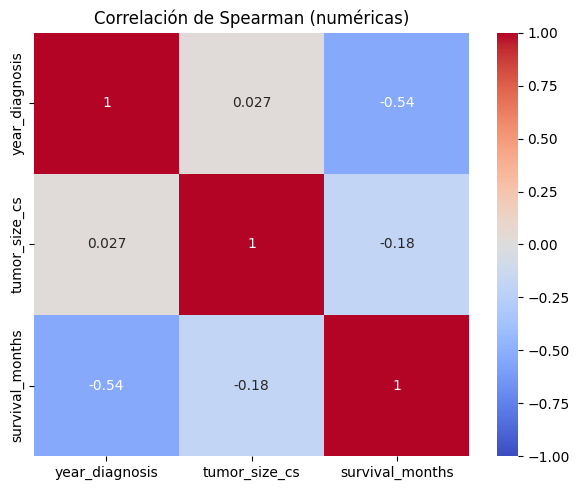

In [42]:
num_vars_corr = ['year_diagnosis', 'tumor_size_cs', 'survival_months']

fig, ax = plt.subplots(figsize=(6, 5))
corr = df[num_vars_corr].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlación de Spearman (numéricas)')
plt.tight_layout()
plt.show()

**Nota sobre `year_diagnosis` vs `survival_months` (-0.54):** esta correlación moderada no refleja una tendencia clínica real. Los pacientes diagnosticados más recientemente (`year_diagnosis` alto) llevan, obviamente, menos tiempo de seguimiento posible hasta el corte del estudio, así que su `survival_months` está limitado, independientemente de su pronóstico real. No debe interpretarse como que el año de diagnóstico causa menor supervivencia.

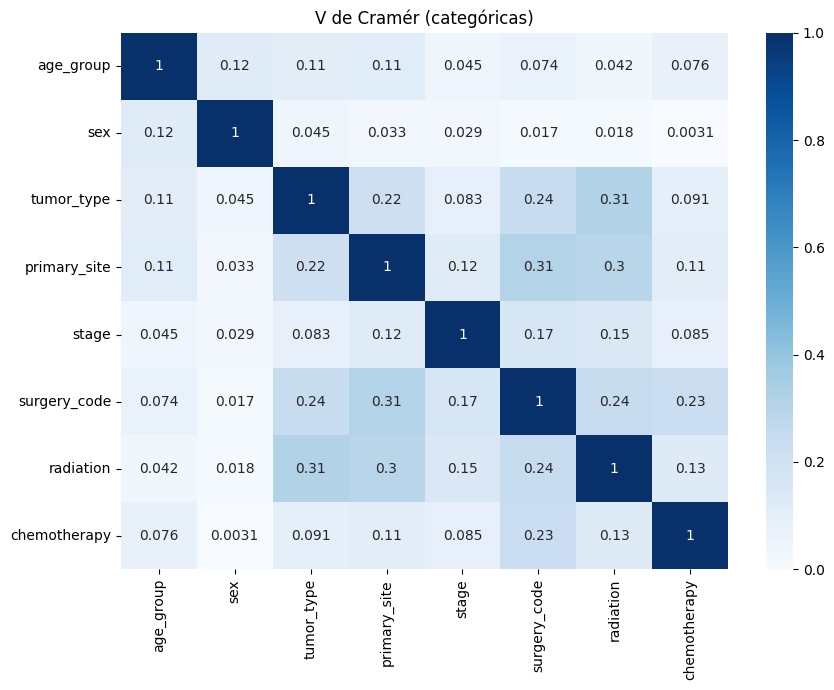

In [43]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

mat = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for i in cat_vars:
    for j in cat_vars:
        mat.loc[i, j] = cramers_v(df[i], df[j])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title("V de Cramér (categóricas)")
plt.tight_layout()
plt.show()

### Interpretación

- **Numéricas:** sin correlación relevante entre predictores reales, no hay riesgo de multicolinealidad. La única correlación que se debe mencionar es `year_diagnosis` vs `survival_months`, ya que esta correlación moderada no refleja una tendencia clínica real. Los pacientes diagnosticados más recientemente (`year_diagnosis` alto) llevan, obviamente, menos tiempo de seguimiento posible hasta el corte del estudio, así que su `survival_months` está limitado, independientemente de su pronóstico real. No debe interpretarse como que el año de diagnóstico causa menor supervivencia.

- **Categóricas:** todas las asociaciones son moderadas o débiles, sin ningún par aproximandose a un umbral de 0.7 o 0.8. Tiene sentido clínico que las variables de tratamiento como `surgery_code`, `radiation` y `chemotherapy` estén moderadamente asociadas entre sí y con `tumor_type` o `primary_site`. Las decisiones de tratamiento dependen del tipo y localización del tumor. No se detecta ninguna pareja que obligue a eliminar una variable por redundancia antes del modelado.

No hay evidencia, teniendo en cuenta los resultados, de multicolinealidad entre las variables predictoras. Todas las variables categóricas y numéricas pueden incluirse en el modelo sin riesgo de redundancia severa.

## 9) Conclusiones del EDA para el modelado

Se resumen los hallazgos de las secciones anteriores en una tabla, para así saber las decisiones concretas que se deben tomar en el notebook de modelado `03_modelo_ML.ipynb`.
El objetivo es que ninguna de ellas se tome sin una justificación exploratoria previa documentada en este notebook.

| Hallazgo | Sección | Implicación para el modelado |
|---|---|---|
| Distribución de `target` algo optimista frente a Kaplan-Meier (68.4% a 5 años vs 71.6% de `target=0`) | 3, 7 | Tener en cuenta al interpretar métricas del modelo de clasificación |
| 74 duplicados exactos, concentrados en missing de `tumor_size_cs` | 4 | Eliminar antes del `train_test_split` (riesgo de data leakage) |
| Caso de 486mm en `Skull/head/jaw` (05-09 years) | 4 | Candidato a revisión |
| Categorías con muy pocos casos: subtipos de `tumor_type`, `CNS/meninges`, estados intermedios de `stage` | 4, 5, 7 | Agrupar subtipos minoritarios de `tumor_type` y estados intermedios de `stage`. `CNS/meninges` (32 casos) se mantiene sin agrupar pese a su bajo volumen ya que es la categoría con peor supervivencia de `primary_site` y salió significativa en el bivariante (chi2=61.04, p=9.37e-11).|
| `stage` es el factor dominante de predicción (mayor chi2 y log-rank con diferencia) | 5, 7 | Predictor principal esperado, alta importancia esperable en SHAP |
| `surgery_code` y `primary_site` también muestran asociación fuerte y clínicamente coherente | 5, 7 | Priorizar como predictores junto a `stage` |
| `chemotherapy` no significativa (p=0.077), fuerte desbalanceo | 5 | Aporta poca señal, mantener sin esperar gran capacidad predictiva |
| Missing en `stage`/`tumor_size_cs`/`surgery_code` depende del año, no del paciente | 6 | No usar `dropna()` global ni imputación |
| `tumor_size_cs` sin cobertura fuera de 2004-2015 | 4, 6 | No usar como predictor principal, ya descartado en `01_limpieza.ipynb` (posible submodelo opcional 2004-2015) |
| `surgery_code` 100% missing solo en 2023 (210 casos) | 6 | Dejar como `NaN` nativo, sin excluir filas |
| Correlación `year_diagnosis`-`survival_months` (-0.54) no es relación real | 8 | No interpretar como causa; no genera multicolinealidad real |
| Sin multicolinealidad problemática | 8 | Todas las variables pueden incluirse sin riesgo de redundancia |

> `stage` es el factor pronóstico dominante, seguido de `surgery_code` y `primary_site`, basado en tres análisis independientes (bivariante, Kaplan-Meier, correlaciones). No hay multicolinealidad problemática ni inconsistencias que obliguen a modificar el dataset en esta fase. 

> Pendiente para `03_modelo_ML.ipynb`: eliminar duplicados antes del split, tratar el missing según el año, y agrupaciones de categorías minoritarias en `tumor_type`, `primary_site` y `stage`.